# ✋ Sign Language Recognition Using Deep Learning  
## Week 2 — Image Preprocessing and Data Augmentation

---

## Introduction

In Week 1, I explored the ASL Alphabet dataset and analyzed its folder structure, class distribution, image samples, and pixel values.

In Week 2, I focus on preparing the image dataset for CNN model training.

This week is important because raw images cannot be directly used without preprocessing.  
The images need to be resized, normalized, split into training and validation sets, and augmented.

Data augmentation is one of the most important steps because it helps the model become more flexible and reduces overfitting.

## Week 2 Goals

The main goals of Week 2 are:

- load the extracted ASL Alphabet dataset;
- define image size for CNN input;
- create training and validation generators;
- normalize pixel values;
- apply data augmentation;
- visualize augmented images;
- prepare the dataset pipeline for CNN training in Week 3.

In [17]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Checking Dataset Files

The dataset was downloaded from Kaggle and extracted in Week 1.

Before preprocessing, I check whether the dataset files are available in the current Colab environment.

In [18]:
print(os.listdir())

['.config', 'kaggle.json', 'sample_data']


## Extract Dataset if Needed

If the dataset ZIP file exists, I extract it into the `data/` folder.

If it was already extracted, this step can still be safely skipped or re-run.

In [19]:
# Install Kaggle library
!pip install -q kaggle

In [25]:
!kaggle datasets download -d grassknoted/asl-alphabet

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:10<00:00, 103MB/s]



In [26]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [21]:
# Upload kaggle.json file

from google.colab import files

files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"darynminal","key":"6b38091e2cb8901c5eb56442ea926569"}'}

In [27]:
if os.path.exists("asl-alphabet.zip"):
    with zipfile.ZipFile("asl-alphabet.zip", "r") as zip_ref:
        zip_ref.extractall("data")

    print("Dataset extracted successfully into data/ folder.")
else:
    print("ZIP file not found. If the dataset is already extracted, continue to the next cell.")

Dataset extracted successfully into data/ folder.


## Finding the Training Dataset Folder

The ASL Alphabet dataset contains a folder with class subfolders such as:

```text
A, B, C, ..., Z, del, nothing, space

In [28]:
dataset_path = None

for root, dirs, files in os.walk("."):
    if len(dirs) >= 20:
        if any(class_name in dirs for class_name in ["A", "B", "C", "space", "nothing"]):
            dataset_path = root
            break

print("Dataset path:", dataset_path)

Dataset path: ./data/asl_alphabet_train/asl_alphabet_train


In [29]:
class_names = sorted([
    class_name for class_name in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, class_name))
])

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## Image Size Selection

For CNN training, all images must have the same size.

I selected:

```text
64 × 64

## Data Preprocessing Strategy

The preprocessing pipeline includes:

1. resizing images to 64×64;
2. normalizing pixel values from 0–255 to 0–1;
3. splitting the data into training and validation sets;
4. applying data augmentation to training images.

This prepares the dataset for CNN training.

## Data Augmentation

Data augmentation creates slightly modified versions of training images.

For this project, I use:

- rotation;
- zoom;
- width shift;
- height shift;
- horizontal flip;
- brightness changes.

This helps the model learn gestures more generally instead of memorizing exact images.

In [39]:
IMG_SIZE = 64
BATCH_SIZE = 32
SEED = 42

In [30]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False
)

validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

## Training Data Generator

The training generator loads images from folders, resizes them, normalizes them, and applies augmentation.

In [43]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED
)

Found 69600 images belonging to 29 classes.


## Validation Data Generator

The validation generator loads validation images without augmentation.

Only normalization is applied.

In [44]:
validation_generator = validation_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED
)

Found 17400 images belonging to 29 classes.


## Checking Generator Information

Now I check class mapping, number of classes, and batch shape.

In [45]:
print("Class indices:")
print(train_generator.class_indices)

print("\nNumber of classes:", train_generator.num_classes)
print("Number of training images:", train_generator.samples)
print("Number of validation images:", validation_generator.samples)

Class indices:
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28}

Number of classes: 29
Number of training images: 69600
Number of validation images: 17400


In [46]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel min value:", images.min())
print("Pixel max value:", images.max())

Image batch shape: (32, 64, 64, 3)
Label batch shape: (32, 29)
Pixel min value: 0.0
Pixel max value: 1.0


## Observation

The image batch shape shows:

```text
batch_size × height × width × channels

## Visualizing Preprocessed Images

Now I visualize several preprocessed images from the training generator.

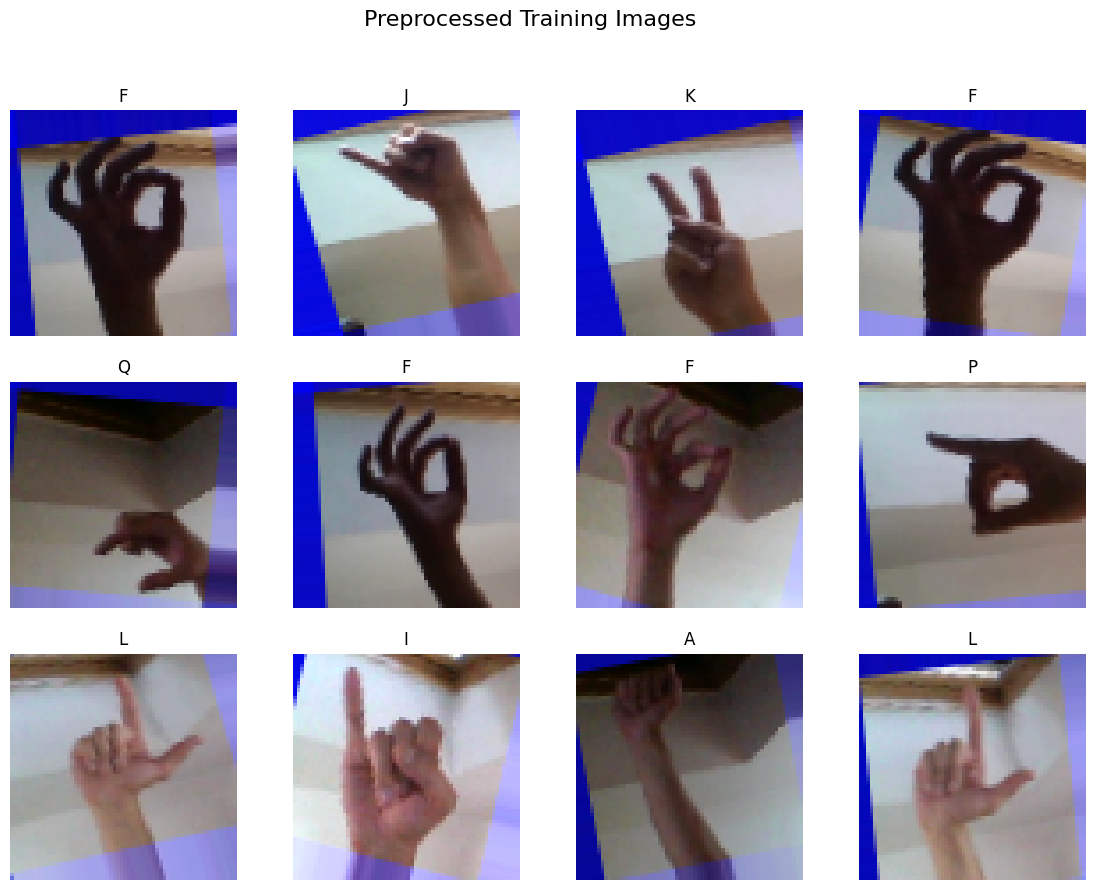

In [47]:
class_indices = train_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

plt.figure(figsize=(14, 10))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])

    label_index = np.argmax(labels[i])
    plt.title(index_to_class[label_index])

    plt.axis("off")

plt.suptitle("Preprocessed Training Images", fontsize=16)
plt.show()

## Visualizing Augmentation Effect

To understand how augmentation changes images, I select one image and generate several augmented versions.

This shows how the model will see different variations of the same gesture during training.

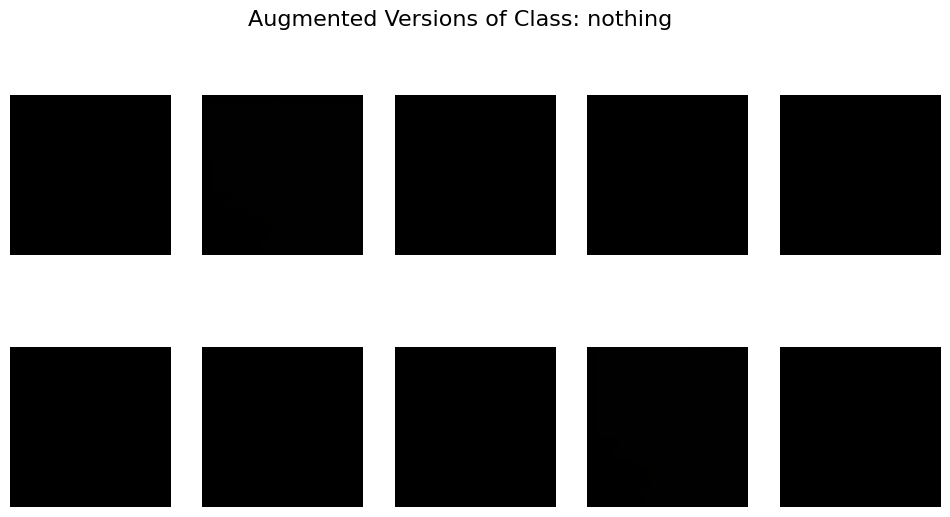

In [52]:
image_array = np.array(display_image) / 255.0
image_array = np.expand_dims(image_array, axis=0)

augmented_iterator = train_datagen.flow(
    image_array,
    batch_size=1
)

plt.figure(figsize=(12, 6))

for i in range(10):
    augmented_image = next(augmented_iterator)[0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(augmented_image)
    plt.axis("off")

plt.suptitle(f"Augmented Versions of Class: {random_class}", fontsize=16)
plt.show()

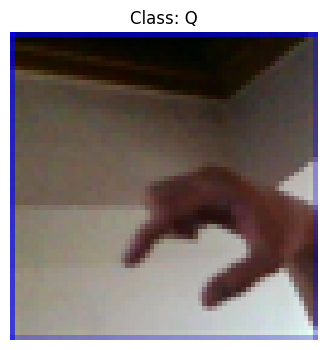

In [54]:
random_class = random.choice(class_names)
class_folder = os.path.join(dataset_path, random_class)
image_files = [
    file for file in os.listdir(class_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]
image_file = random.choice(image_files)
image_path = os.path.join(class_folder, image_file)
image = Image.open(image_path).convert("RGB")
image = image.resize((IMG_SIZE, IMG_SIZE))
image_array = np.array(image)
# Normalize ONLY for display
image_array = image_array.astype("float32")
image_array = (image_array - image_array.min()) / (
    image_array.max() - image_array.min() + 1e-8
)
plt.figure(figsize=(4,4))
plt.imshow(image_array)
plt.title(f"Class: {random_class}")
plt.axis("off")
plt.show()

## Why Data Augmentation Matters

Data augmentation is useful because it helps the model handle small variations in real images.

For example, when users upload hand gesture images, the hand may be:

- slightly rotated;
- closer or farther from the camera;
- shifted left or right;
- shown with different brightness.

Augmentation prepares the model for these real-world differences.

## Class Distribution After Generator Loading

I also check how many images are used for training and validation.

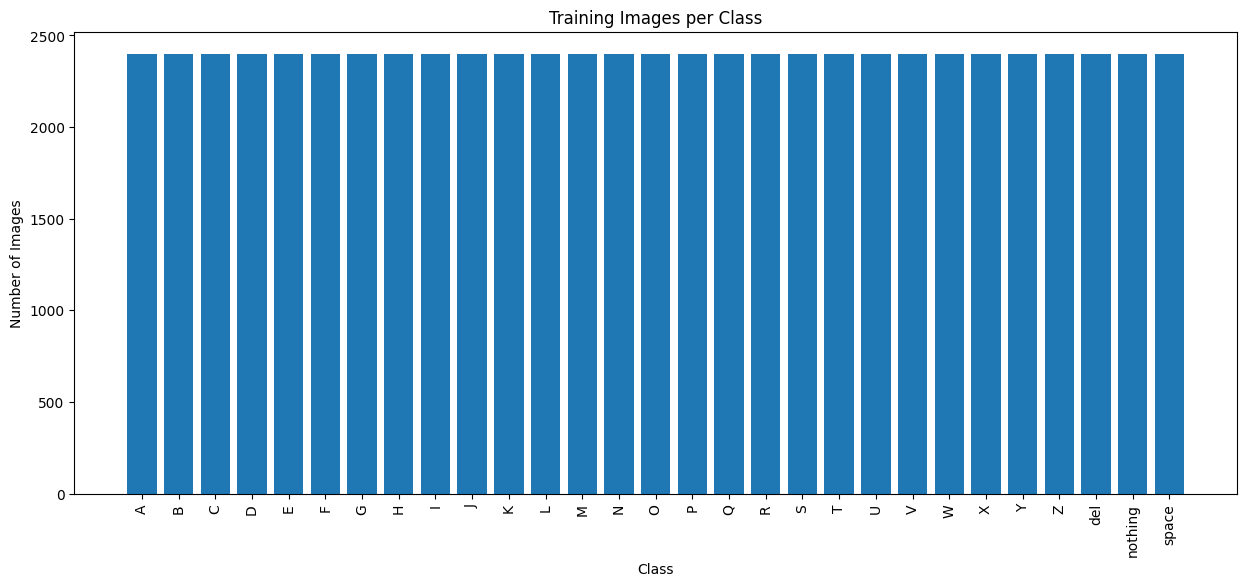

In [55]:
train_class_counts = np.bincount(train_generator.classes)
val_class_counts = np.bincount(validation_generator.classes)

plt.figure(figsize=(15, 6))

plt.bar(index_to_class.values(), train_class_counts)

plt.title("Training Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)

plt.show()

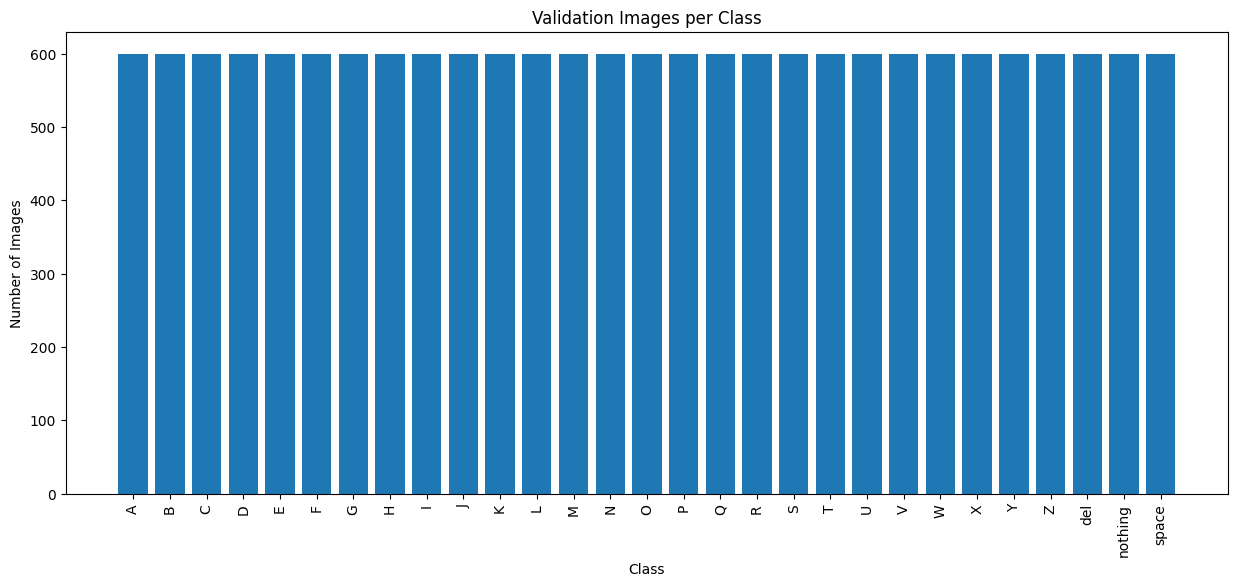

In [56]:
plt.figure(figsize=(15, 6))

plt.bar(index_to_class.values(), val_class_counts)

plt.title("Validation Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)

plt.show()

## Prepared Data Summary

After preprocessing, the dataset is ready for CNN model training.

| Item | Value |
|---|---|
| Image size | 64×64 |
| Color channels | 3 |
| Pixel range | 0–1 |
| Batch size | 32 |
| Label format | Categorical |
| Augmentation | Applied to training set |
| Validation split | 20% |

## Key Findings

During Week 2, I completed the preprocessing pipeline:

- images were resized;
- pixel values were normalized;
- training and validation generators were created;
- data augmentation was applied;
- augmented images were visualized;
- the CNN input pipeline was prepared.

This week is important because a good preprocessing pipeline directly affects model performance.

## Plan for Week 3

In Week 3, I will start CNN model training.

The next tasks are:

- build a custom CNN architecture;
- train the model using the prepared generators;
- track accuracy and loss;
- evaluate performance on validation data;
- save the trained model into the `models/` folder.

## Week 2 Conclusion

Week 2 focused on image preprocessing and data augmentation for the ASL Alphabet dataset.

The dataset was successfully prepared for CNN training.

The most important result of this week is that the images are now resized, normalized, augmented, and organized through training and validation generators.

This creates a strong foundation for Week 3 model training.